# Comparación de modelos cosmológicos

Todos los modelos (a excepción de FlatLCDM) tienen libre el parámetro de curvatura.

In [1]:
import corner
import matplotlib.pyplot as plt
import numpy as np
import pymultinest
import pandas as pd

In [2]:
# cargar cadenas
s1 = np.loadtxt('Omega_L/post_equal_weights.dat')
s2 = np.loadtxt('Omega_w/post_equal_weights.dat')
s3 = np.loadtxt('Omega_wa/post_equal_weights.dat')
s4 = np.loadtxt('Omega_k/post_equal_weights.dat')

In [8]:
# columnas de parámetros
samples1 = s1[:, :-1]
samples2 = s2[:, :-2]
samples3 = s3[:, :-3]
samples4 = s4[:, :-1]

########## FlatLambdaCDM #######
Omega_L = samples1[:, -1]                  ## samples1 = ["a","b","M","OL"]
Omega_M = 1.0 - Omega_L

samples1 = np.insert(samples1, 3, Omega_M, axis=1)   

########## wLCDM (k=0) #######
Omega_M = samples2[:, -1]                  ## samples2 = ["a","b","M","OM"]
Omega_L = 1.0 - Omega_M

samples2 = np.insert(samples2, 4, Omega_L, axis=1)


########## w0waLCDM (k=0) #######
Omega_M = samples3[:, -1]                  ## samples2 = ["a","b","M","OM"]
Omega_L = 1.0 - Omega_M

samples3 = np.insert(samples3, 4, Omega_L, axis=1)


########## LCDM (k!=0) #######
samples4[:, [3, 4]] = samples4[:, [4, 3]]                  ## samples2 = ["a","b","M","OL","OM"]

In [9]:
print(samples1[0])
print(samples2[0])
print(samples3[0])
print(samples4[0])

[  0.13340192   2.40337816 -19.3502634    0.3556926    0.6443074 ]
[  0.1389127    2.48204551 -19.3254478    0.30695725   0.69304275]
[  0.13361177   2.34443881 -19.30831934   0.29925725   0.70074275]
[  0.13133418   2.40258389 -19.32207495   0.54439472   0.35011641]


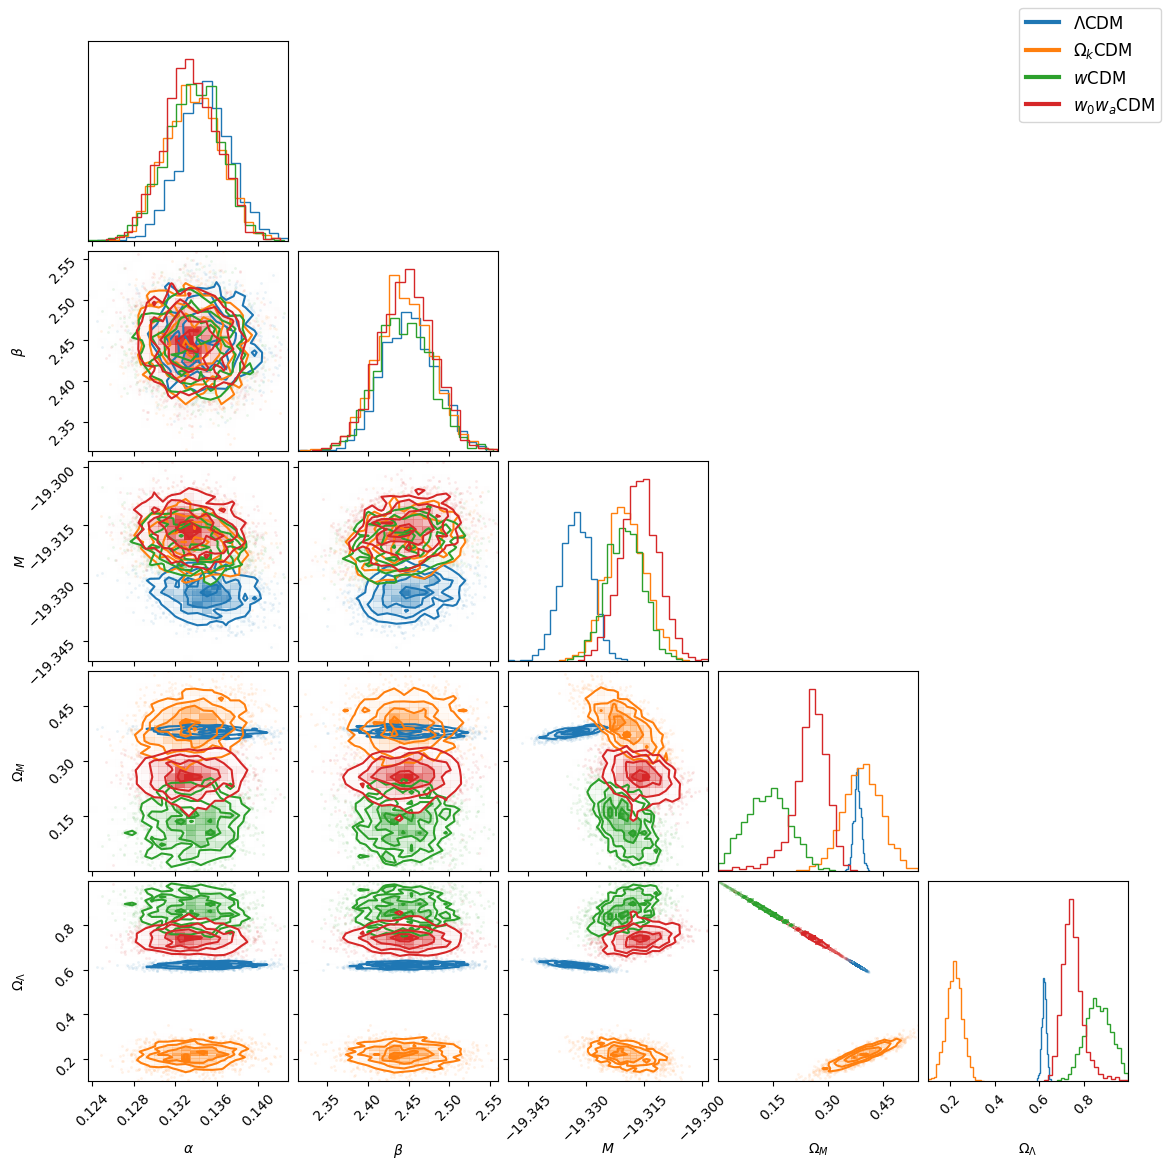

In [11]:
labels = [r'$\alpha$', r'$\beta$', r'$M$', r'$\Omega_M$', r'$\Omega_\Lambda$']

corner.corner(samples1,
              color='C0',
              labels=labels)

corner.corner(samples4,
              color='C1',
              fig=plt.gcf())

corner.corner(samples2,
              color='C2',
              fig=plt.gcf())

corner.corner(samples3,
              color='C3',
              fig=plt.gcf())


from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='C0', lw=3, label=r'$\Lambda$CDM'),
    Line2D([0], [0], color='C1', lw=3, label=r'$\Omega_k$CDM'),
    Line2D([0], [0], color='C2', lw=3, label=r'$w$CDM'),
    Line2D([0], [0], color='C3', lw=3, label=r'$w_0w_a$CDM')
]

plt.gcf().legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=12
)

plt.show()

# Criterios AIC/BIC

Un ajuste basado únicamente en el máximo likelihood tiende a favorecer modelos con más parámetros. Para compensar este efecto se emplean criterios de información que penalizan la complejidad del modelo $\text{\small \textcolor{blue}{[Liddle, 2004]}}$. El criterio de información de Akaike (AIC) se define como 
\begin{equation}
\text{AIC} = -2 \ln \mathcal{L} + 2 k
\end{equation}
donde L es el máximo likelihood y k el número de parámetros libres. El modelo preferido es aquel que minimiza el valor del AIC.
De manera análoga, el criterio de información bayesiano (BIC) está dado por
\begin{equation}
\text{BIC} = -2 \ln \mathcal{L} + k \ln N
\end{equation}
donde N es el número de datos utilizados en el ajuste. El BIC introduce una penalización más fuerte para modelos con un mayor número de parámetros y constituye una aproximación al factor de Bayes.
Tanto para el AIC como para el BIC, únicamente son relevantes las diferencias entre modelos, siendo preferidos aquellos con valores menores. Como alternativa más rigurosa, puede emplearse la evidencia bayesiana, que compara modelos mediante la integración del likelihood sobre todo el espacio de parámetros, incorporando de forma natural la información previa.

In [12]:
files = ["L", "k", "w", "wa"]
names = ["FlatLCDM", "LCDM", r"$w$CDM", r"$w_0w_a$CDM"]
resultados = []
N = 1701

for file, name in zip(files, names):
    path = 'Omega_' + file + '/'
    a = pymultinest.Analyzer(n_params = 1, outputfiles_basename=path)
    stats = a.get_stats()
    log_ev = stats['global evidence']
    chains = a.get_equal_weighted_posterior()
    loglikes = chains[:,-1]
    loglMax = np.max(loglikes)
    chi2_min = -loglMax                           ## LogLike = -chi2
    k = len(chains[0])-1
    aic = chi2_min + 2*k
    bic = chi2_min +k*np.log(N)
    resultados.append({'Modelo': name,'k': k, 'N': N,
    'chi2_min': chi2_min,
    'AIC': aic,
    'BIC': bic,
    'logZ': log_ev})

  analysing data from Omega_L/.txt
  analysing data from Omega_k/.txt
  analysing data from Omega_w/.txt
  analysing data from Omega_wa/.txt


In [13]:
tabla = pd.DataFrame(resultados).round(2).set_index('Modelo')

tabla

,k,N,chi2_min,AIC,BIC,logZ
Modelo,,,,,,
FlatLCDM,4,1701,2001.78,2009.78,2031.53,-2023.55
LCDM,5,1701,1989.79,1999.79,2026.98,-2013.12
$w$CDM,5,1701,1988.48,1998.48,2025.67,-2012.47
$w_0w_a$CDM,6,1701,1984.75,1996.75,2029.38,-2010.33
